load dataset

In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [50]:
import pandas as pd

df = pd.read_csv(path + "/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Eda


In [51]:
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
df = df.rename(columns={"v1": "label", "v2": "text"})
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [52]:
df.isna().sum()

,0
label,0
text,0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [54]:
df.shape

(5572, 2)

In [55]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [56]:
df = pd.DataFrame(df)
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


clean text


In [57]:
df['text']=df['text'].str.lower()
df.head()

,label,text
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [58]:
df = df.drop_duplicates(keep='first')

In [59]:
import re
def clean_text (text) :
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  return text
df['text']=df['text'].apply(clean_text)
df['text'].head()


,text
0,go until jurong point crazy available only ...
1,ok lar joking wif u oni
2,free entry in a wkly comp to win fa cup fina...
3,u dun say so early hor u c already then say
4,nah i don t think he goes to usf he lives aro...


In [60]:
df['text'] = df['text'].str.split().str.join(' ')
df.head()

,label,text
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i don t think he goes to usf he lives arou...


In [61]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True)
x = vectorizer.fit_transform(df['text']).toarray()
y = df['label']
x.shape

(5168, 11781)

In [63]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [64]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = classification_report(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       891
        spam       1.00      0.76      0.87       143

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [65]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced")
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = classification_report(y_test, y_pred)
print( accuracy)

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       891
        spam       0.95      0.91      0.93       143

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [66]:
from sklearn.svm import SVC
model = SVC(    kernel="linear",     class_weight="balanced")
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = classification_report(y_test, y_pred)
print(accuracy)

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       891
        spam       0.99      0.89      0.94       143

    accuracy                           0.98      1034
   macro avg       0.99      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



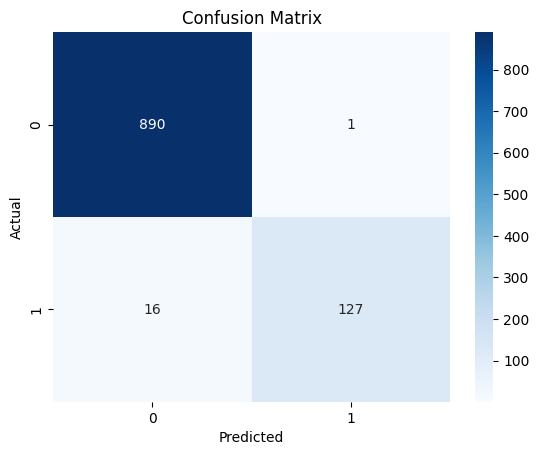

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer2 = TfidfVectorizer(max_features=5000,ngram_range=(1,2),stop_words="english")
x2 = vectorizer2.fit_transform(df['text']).toarray()
y2 = df['label']
x2.shape

(5168, 5000)

In [69]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x2,y,test_size=0.2,random_state=42)

In [70]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = classification_report(y_test, y_pred)
print( accuracy)

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       891
        spam       1.00      0.76      0.86       143

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



In [71]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = classification_report(y_test, y_pred)
print( accuracy)

              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       891
        spam       0.99      0.62      0.76       143

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.95      0.95      0.94      1034



In [72]:
from sklearn.svm import SVC
model = SVC()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = classification_report(y_test, y_pred)
print( accuracy)

              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       891
        spam       0.99      0.84      0.91       143

    accuracy                           0.98      1034
   macro avg       0.98      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034

